# RNN Discriminator Training with Attention Pooling

Train a bidirectional GRU discriminator with attention pooling to classify real vs fake motion clips.
This notebook visualizes attention weights to understand which timesteps are most discriminative.

In [1]:
import os
import time
from typing import Dict, List, Tuple

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

# Set environment variables before importing track_mjx
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from track_mjx.analysis.discriminator import (
    MotionClipDataset,
    create_train_test_split,
    load_h5_dataset,
    load_h5_metadata,
    make_rnn_discriminator_network,
)
from track_mjx.analysis.discriminator.data_loading import create_batches
from track_mjx.analysis.discriminator.discriminator_train import (
    DiscriminatorParams,
    TrainingState,
    binary_cross_entropy_loss,
    compute_accuracy,
    create_eval_step,
    create_train_step,
    evaluate,
)

## Configuration

Set the path to your H5 dataset and configure RNN discriminator parameters.

In [45]:
# Data configuration
H5_PATH = "/home/mila/a/aidan.sirbu/track-mjx/data/discriminator_dataset_260115_160947_201609_23.h5"

# Available datasets from collect_rollout_dataset.py:
#   - original_qpos: Original reference motion capture data
#   - encoder_decoder_qpos: Rollouts from encoder-decoder pipeline
#   - prior_logvar_-4_qpos: Prior rollouts with logvar=-4 (std~0.14)
#   - prior_logvar_-2_qpos: Prior rollouts with logvar=-2 (std~0.37)
#   - prior_logvar_0_qpos: Prior rollouts with logvar=0 (std=1.0)
#   - prior_deterministic_qpos: Prior rollouts using mean (no sampling)
#   - prior_predicted_logvar_qpos: Prior rollouts using network-predicted logvar
REAL_DATASET = "encoder_decoder_qpos"  # Dataset name for "real" samples
FAKE_DATASET = "prior_logvar_-4_qpos"  # Dataset name for "fake" samples
TRAIN_RATIO = 0.8
SPLIT_SEED = 42

# Clip/time truncation configuration
# Option 1: Use CLIP_START and CLIP_END to extract a specific time range
# Option 2: Use CLIP_LENGTH alone to truncate from the beginning
# Set all to None to use full clips
CLIP_START = None  # Start timestep (inclusive), e.g., 50 to skip first 50 steps
CLIP_END = None  # End timestep (exclusive), e.g., 200 to stop at step 199
CLIP_LENGTH = (
    250  # Alternative: truncate to first N steps (ignored if CLIP_START/END are set)
)

# Window configuration
# Set to None to use full clips, or a divisor of the final clip length
WINDOW_SIZE = 10  # Number of time steps per window (must divide clip length evenly)

# RNN Network configuration
RNN_HIDDEN_SIZE = 128  # Hidden size for each GRU direction
RNN_NUM_LAYERS = 2  # Number of stacked GRU layers
RNN_BIDIRECTIONAL = True  # Use bidirectional GRU
ATTENTION_HIDDEN_SIZE = 64  # Hidden size for attention pooling
DROPOUT_RATE = 0.1

# Training configuration
NUM_EPOCHS = 100
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 1.0
SEED = 0

# Data filtering options
EXCLUDE_ROOT = False  # Exclude first 7 qpos dims (root position + quaternion)
EXCLUDE_ZERO_JOINTS = False  # Exclude joints that are always zero

## Load Data

In [46]:
# Check if using single dataset mode (baseline)
single_dataset_mode = REAL_DATASET == FAKE_DATASET
if single_dataset_mode:
    print(f"Single dataset mode: both real and fake use '{REAL_DATASET}'.")
    print(
        "This is a baseline where the network should NOT learn (expected ~50% accuracy)."
    )

# Load datasets
print(f"Loading data from: {H5_PATH}")
print(f"Real dataset: {REAL_DATASET}")
print(f"Fake dataset: {FAKE_DATASET}")

real_data = load_h5_dataset(H5_PATH, REAL_DATASET)
fake_data = load_h5_dataset(H5_PATH, FAKE_DATASET)
metadata = load_h5_metadata(H5_PATH)

original_num_steps = real_data.shape[1]
print(f"\nReal data shape: {real_data.shape}")
print(f"Fake data shape: {fake_data.shape}")
print(f"H5 metadata: {metadata}")

# Apply time truncation
# Priority: CLIP_START/CLIP_END > CLIP_LENGTH
if CLIP_START is not None or CLIP_END is not None:
    # Use start/end range
    start = CLIP_START if CLIP_START is not None else 0
    end = CLIP_END if CLIP_END is not None else original_num_steps

    # Validate
    if start < 0:
        raise ValueError(f"CLIP_START ({start}) cannot be negative")
    if end > original_num_steps:
        raise ValueError(
            f"CLIP_END ({end}) cannot exceed num_steps ({original_num_steps})"
        )
    if start >= end:
        raise ValueError(f"CLIP_START ({start}) must be less than CLIP_END ({end})")

    real_data = real_data[:, start:end, :]
    fake_data = fake_data[:, start:end, :]

    print(f"\nExtracted time range [{start}:{end}] ({end - start} steps)")
    print(f"  Real data shape: {real_data.shape}")
    print(f"  Fake data shape: {fake_data.shape}")

elif CLIP_LENGTH is not None:
    # Use simple length truncation from beginning
    if CLIP_LENGTH > original_num_steps:
        raise ValueError(
            f"CLIP_LENGTH ({CLIP_LENGTH}) cannot exceed original num_steps ({original_num_steps})"
        )
    real_data = real_data[:, :CLIP_LENGTH, :]
    fake_data = fake_data[:, :CLIP_LENGTH, :]
    print(
        f"\nTruncated clips to first {CLIP_LENGTH} time steps (discarded last {original_num_steps - CLIP_LENGTH})"
    )
    print(f"  Real data shape: {real_data.shape}")
    print(f"  Fake data shape: {fake_data.shape}")

# Effective number of time steps after truncation
num_steps = real_data.shape[1]

# Validate window size
if WINDOW_SIZE is not None:
    if num_steps % WINDOW_SIZE != 0:
        valid_divisors = [i for i in range(1, num_steps + 1) if num_steps % i == 0]
        raise ValueError(
            f"WINDOW_SIZE ({WINDOW_SIZE}) must evenly divide num_steps ({num_steps}). "
            f"Valid window sizes: {valid_divisors}"
        )
    num_windows = num_steps // WINDOW_SIZE
    print(f"\nWindow size: {WINDOW_SIZE} time steps")
    print(f"Each clip will be split into {num_windows} windows")
else:
    print(f"\nUsing full clips ({num_steps} time steps)")

Loading data from: /home/mila/a/aidan.sirbu/track-mjx/data/discriminator_dataset_260115_160947_201609_23.h5
Real dataset: encoder_decoder_qpos
Fake dataset: prior_logvar_-4_qpos

Real data shape: (842, 250, 74)
Fake data shape: (842, 250, 74)
H5 metadata: {'checkpoint_path': '/home/mila/a/aidan.sirbu/scratch/track-mjx/model_checkpoints/260115_160947_201609', 'logvars': array([-4. , -3. , -2. , -1. , -0.5,  0. ]), 'num_clips': np.int64(842), 'num_steps': np.int64(250), 'qpos_dim': np.int64(74)}

Truncated clips to first 250 time steps (discarded last 0)
  Real data shape: (842, 250, 74)
  Fake data shape: (842, 250, 74)

Window size: 10 time steps
Each clip will be split into 25 windows


In [47]:
# Create train/test splits
dataset = create_train_test_split(
    real_data=real_data,
    fake_data=fake_data,
    train_ratio=TRAIN_RATIO,
    seed=SPLIT_SEED,
    single_dataset_mode=single_dataset_mode,
)

print(f"Train samples: {len(dataset.train_real)} real, {len(dataset.train_fake)} fake")
print(f"Test samples: {len(dataset.test_real)} real, {len(dataset.test_fake)} fake")

Train samples: 673 real, 673 fake
Test samples: 169 real, 169 fake


## Prepare Data (Apply Filtering and Windowing)

In [48]:
# Indices of joints that are always zero in the data
ZERO_JOINT_INDICES = [
    18,
    24,
    25,
    26,
    27,
    28,
    29,
    30,
    31,
    32,
    33,
    34,
    35,
    36,
    37,
    38,
    39,
    40,
    41,
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    57,
    65,
    73,
]

# Determine which qpos indices to keep
all_indices = set(range(74))  # Original qpos has 74 dimensions
indices_to_exclude = set()

if EXCLUDE_ROOT:
    indices_to_exclude.update(range(7))
    print("Excluding root (indices 0-6): root position + quaternion")

if EXCLUDE_ZERO_JOINTS:
    indices_to_exclude.update(ZERO_JOINT_INDICES)
    print(f"Excluding zero joints ({len(ZERO_JOINT_INDICES)} indices)")

# Compute indices to keep
indices_to_keep = sorted(all_indices - indices_to_exclude)

if len(indices_to_keep) < 74:
    print(
        f"Keeping {len(indices_to_keep)} of 74 qpos dimensions (excluding {74 - len(indices_to_keep)})"
    )
    dataset = MotionClipDataset(
        train_real=dataset.train_real[:, :, indices_to_keep],
        train_fake=dataset.train_fake[:, :, indices_to_keep],
        test_real=dataset.test_real[:, :, indices_to_keep],
        test_fake=dataset.test_fake[:, :, indices_to_keep],
        metadata=dataset.metadata,
    )


def split_clips_into_windows(data: np.ndarray, window_size: int) -> np.ndarray:
    """Split clips into smaller windows along the time dimension."""
    num_clips, num_steps, qpos_dim = data.shape
    num_windows = num_steps // window_size
    reshaped = data.reshape(num_clips, num_windows, window_size, qpos_dim)
    return reshaped.reshape(-1, window_size, qpos_dim)


# Apply windowing if configured (AFTER train/test split to avoid data leakage)
if WINDOW_SIZE is not None:
    original_train_real = len(dataset.train_real)
    original_train_fake = len(dataset.train_fake)
    original_test_real = len(dataset.test_real)
    original_test_fake = len(dataset.test_fake)

    dataset = MotionClipDataset(
        train_real=split_clips_into_windows(dataset.train_real, WINDOW_SIZE),
        train_fake=split_clips_into_windows(dataset.train_fake, WINDOW_SIZE),
        test_real=split_clips_into_windows(dataset.test_real, WINDOW_SIZE),
        test_fake=split_clips_into_windows(dataset.test_fake, WINDOW_SIZE),
        metadata=dataset.metadata,
    )

    print(f"\nAfter windowing (window_size={WINDOW_SIZE}):")
    print(
        f"  Train real: {original_train_real} clips -> {len(dataset.train_real)} windows"
    )
    print(
        f"  Train fake: {original_train_fake} clips -> {len(dataset.train_fake)} windows"
    )
    print(
        f"  Test real: {original_test_real} clips -> {len(dataset.test_real)} windows"
    )
    print(
        f"  Test fake: {original_test_fake} clips -> {len(dataset.test_fake)} windows"
    )

# Determine input shape from data
sample_shape = dataset.train_real.shape[1:]  # (num_steps or window_size, qpos_dim)
num_steps_final, qpos_dim = sample_shape

print(
    f"\nInput shape: {sample_shape} (num_steps={num_steps_final}, qpos_dim={qpos_dim})"
)


After windowing (window_size=10):
  Train real: 673 clips -> 16825 windows
  Train fake: 673 clips -> 16825 windows
  Test real: 169 clips -> 4225 windows
  Test fake: 169 clips -> 4225 windows

Input shape: (10, 74) (num_steps=10, qpos_dim=74)


## Initialize RNN Network and Optimizer

In [49]:
# Create RNN network (without attention return for training)
_, init_fn, apply_fn = make_rnn_discriminator_network(
    num_steps=num_steps_final,
    qpos_dim=qpos_dim,
    rnn_hidden_size=RNN_HIDDEN_SIZE,
    num_layers=RNN_NUM_LAYERS,
    dropout_rate=DROPOUT_RATE,
    bidirectional=RNN_BIDIRECTIONAL,
    attention_hidden_size=ATTENTION_HIDDEN_SIZE,
    return_attention=False,
)

# Initialize parameters
key = jax.random.PRNGKey(SEED)
init_params = init_fn(key)

# Create optimizer with gradient clipping
optimizer = optax.chain(
    optax.clip_by_global_norm(GRAD_CLIP_NORM),
    optax.adamw(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY),
)

# Initialize training state
training_state = TrainingState(
    optimizer_state=optimizer.init(init_params),
    params=DiscriminatorParams(params=init_params),
    epoch=0,
    step=0,
    best_test_accuracy=0.0,
)

# Create JIT-compiled step functions
train_step_fn = create_train_step(apply_fn, optimizer)
eval_step_fn = create_eval_step(apply_fn)

print(f"RNN Architecture:")
print(f"  Hidden size: {RNN_HIDDEN_SIZE} (x2 if bidirectional)")
print(f"  Num layers: {RNN_NUM_LAYERS}")
print(f"  Bidirectional: {RNN_BIDIRECTIONAL}")
print(f"  Attention hidden: {ATTENTION_HIDDEN_SIZE}")
print(f"  Dropout rate: {DROPOUT_RATE}")

RNN Architecture:
  Hidden size: 128 (x2 if bidirectional)
  Num layers: 2
  Bidirectional: True
  Attention hidden: 64
  Dropout rate: 0.1


## Training Loop

In [50]:
# Storage for metrics
history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
}

# Evaluate before training
initial_test_metrics = evaluate(
    training_state.params.params,
    eval_step_fn,
    dataset.test_real,
    dataset.test_fake,
    BATCH_SIZE,
)

training_state = training_state.replace(
    best_test_accuracy=initial_test_metrics["accuracy"]
)

history["epoch"].append(0)
history["train_loss"].append(None)
history["train_accuracy"].append(None)
history["test_loss"].append(initial_test_metrics["loss"])
history["test_accuracy"].append(initial_test_metrics["accuracy"])

print(
    f"Epoch 0 (before training) - Test Loss: {initial_test_metrics['loss']:.4f}, Test Acc: {initial_test_metrics['accuracy']:.4f}"
)

Epoch 0 (before training) - Test Loss: 0.7027, Test Acc: 0.5011


In [51]:
# Training loop
rng = np.random.default_rng(SEED)

print(f"Training for {NUM_EPOCHS} epochs...\n")

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    epoch_losses = []
    epoch_accuracies = []

    # Generate random keys for this epoch's dropout
    key, epoch_key = jax.random.split(key)
    max_batches = min(len(dataset.train_real), len(dataset.train_fake)) // (
        BATCH_SIZE // 2
    )
    batch_keys = jax.random.split(epoch_key, max_batches + 1)
    batch_idx = 0

    # Training batches
    for batch_data, batch_labels in create_batches(
        dataset.train_real, dataset.train_fake, BATCH_SIZE, rng, shuffle=True
    ):
        batch_data_jax = jnp.array(batch_data)
        batch_labels_jax = jnp.array(batch_labels)

        training_state, metrics = train_step_fn(
            training_state, batch_data_jax, batch_labels_jax, batch_keys[batch_idx]
        )

        epoch_losses.append(float(metrics["loss"]))
        epoch_accuracies.append(float(metrics["accuracy"]))
        batch_idx += 1

    # Update epoch count
    training_state = training_state.replace(epoch=epoch + 1)

    # Compute epoch averages
    train_loss = np.mean(epoch_losses)
    train_accuracy = np.mean(epoch_accuracies)

    # Evaluate on test set
    test_metrics = evaluate(
        training_state.params.params,
        eval_step_fn,
        dataset.test_real,
        dataset.test_fake,
        BATCH_SIZE,
    )

    # Update best accuracy
    if test_metrics["accuracy"] > training_state.best_test_accuracy:
        training_state = training_state.replace(
            best_test_accuracy=test_metrics["accuracy"]
        )

    epoch_time = time.time() - epoch_start

    # Store metrics
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["test_loss"].append(test_metrics["loss"])
    history["test_accuracy"].append(test_metrics["accuracy"])

    # Print progress every 10 epochs or on last epoch
    if (epoch + 1) % 10 == 0 or epoch == NUM_EPOCHS - 1:
        print(
            f"Epoch {epoch + 1:3d}/{NUM_EPOCHS} - "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
            f"Test Loss: {test_metrics['loss']:.4f}, Test Acc: {test_metrics['accuracy']:.4f}, "
            f"Time: {epoch_time:.1f}s"
        )

print(f"\nTraining complete!")
print(f"Best test accuracy: {training_state.best_test_accuracy:.4f}")

Training for 100 epochs...

Epoch  10/100 - Train Loss: 0.5517, Train Acc: 0.6982, Test Loss: 0.7155, Test Acc: 0.5972, Time: 3.3s
Epoch  20/100 - Train Loss: 0.4516, Train Acc: 0.7663, Test Loss: 0.7737, Test Acc: 0.5991, Time: 3.4s
Epoch  30/100 - Train Loss: 0.3625, Train Acc: 0.8195, Test Loss: 1.0002, Test Acc: 0.5879, Time: 3.4s
Epoch  40/100 - Train Loss: 0.2886, Train Acc: 0.8595, Test Loss: 1.1866, Test Acc: 0.5878, Time: 3.4s
Epoch  50/100 - Train Loss: 0.2308, Train Acc: 0.8895, Test Loss: 1.4841, Test Acc: 0.5787, Time: 3.4s
Epoch  60/100 - Train Loss: 0.1867, Train Acc: 0.9103, Test Loss: 1.7399, Test Acc: 0.5754, Time: 3.4s
Epoch  70/100 - Train Loss: 0.1530, Train Acc: 0.9263, Test Loss: 2.1051, Test Acc: 0.5617, Time: 3.3s
Epoch  80/100 - Train Loss: 0.1307, Train Acc: 0.9366, Test Loss: 2.3508, Test Acc: 0.5605, Time: 3.4s
Epoch  90/100 - Train Loss: 0.1102, Train Acc: 0.9474, Test Loss: 2.6124, Test Acc: 0.5566, Time: 3.4s
Epoch 100/100 - Train Loss: 0.0947, Train Acc

## Visualize Training Progress

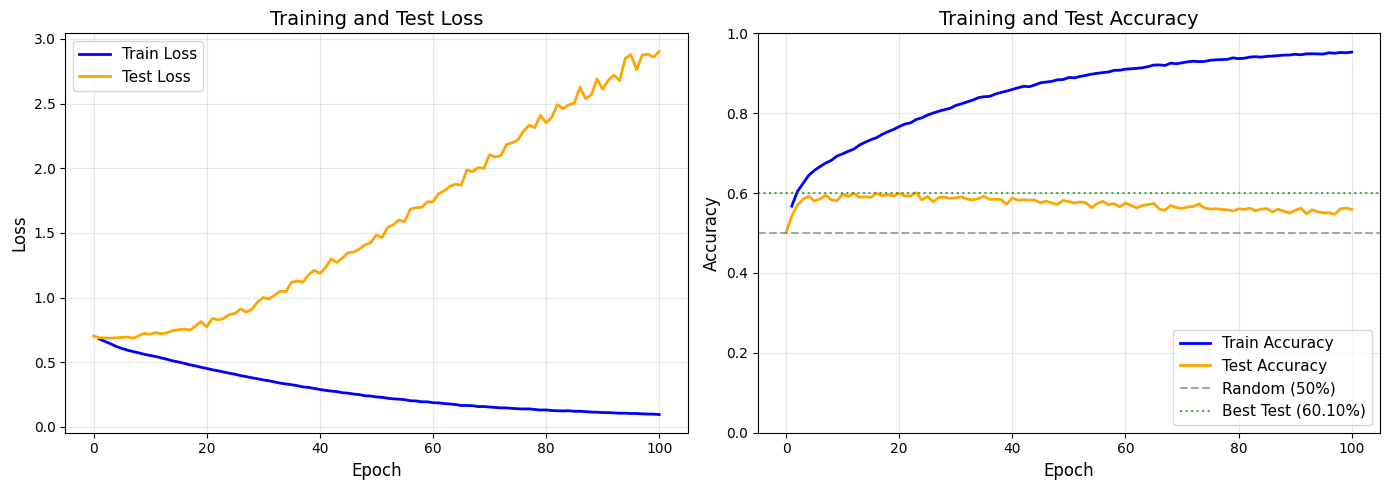

In [52]:
# Convert to arrays for plotting (skip epoch 0 for train metrics since they're None)
epochs = np.array(history["epoch"])
train_epochs = epochs[1:]  # Skip epoch 0
train_loss = np.array([x for x in history["train_loss"] if x is not None])
train_accuracy = np.array([x for x in history["train_accuracy"] if x is not None])
test_loss = np.array(history["test_loss"])
test_accuracy = np.array(history["test_accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1 = axes[0]
ax1.plot(train_epochs, train_loss, label="Train Loss", color="blue", linewidth=2)
ax1.plot(epochs, test_loss, label="Test Loss", color="orange", linewidth=2)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.set_title("Training and Test Loss", fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2 = axes[1]
ax2.plot(
    train_epochs, train_accuracy, label="Train Accuracy", color="blue", linewidth=2
)
ax2.plot(epochs, test_accuracy, label="Test Accuracy", color="orange", linewidth=2)
ax2.axhline(y=0.5, color="gray", linestyle="--", alpha=0.7, label="Random (50%)")
ax2.axhline(
    y=training_state.best_test_accuracy,
    color="green",
    linestyle=":",
    alpha=0.7,
    label=f"Best Test ({training_state.best_test_accuracy:.2%})",
)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.set_title("Training and Test Accuracy", fontsize=14)
ax2.set_ylim(0, 1)
ax2.legend(fontsize=11, loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary Statistics

In [21]:
print("=" * 60)
print("RNN DISCRIMINATOR TRAINING SUMMARY")
print("=" * 60)
print(f"Dataset: {REAL_DATASET} vs {FAKE_DATASET}")
print(f"Single dataset mode: {single_dataset_mode}")
print(f"")
print(f"Network: Bidirectional GRU with Attention Pooling")
print(f"  RNN hidden size: {RNN_HIDDEN_SIZE}")
print(f"  RNN layers: {RNN_NUM_LAYERS}")
print(f"  Bidirectional: {RNN_BIDIRECTIONAL}")
print(f"  Attention hidden: {ATTENTION_HIDDEN_SIZE}")
print(f"")
print(f"Final train accuracy: {train_accuracy[-1]:.4f}")
print(f"Final test accuracy:  {test_accuracy[-1]:.4f}")
print(f"Best test accuracy:   {training_state.best_test_accuracy:.4f}")
print(f"")
print(f"Final train loss: {train_loss[-1]:.4f}")
print(f"Final test loss:  {test_loss[-1]:.4f}")
print("=" * 60)

if single_dataset_mode:
    print("\nNote: Single dataset mode was used (baseline).")
    print("Expected accuracy is ~50% (random chance).")

RNN DISCRIMINATOR TRAINING SUMMARY
Dataset: encoder_decoder_qpos vs original_qpos
Single dataset mode: False

Network: Bidirectional GRU with Attention Pooling
  RNN hidden size: 128
  RNN layers: 2
  Bidirectional: True
  Attention hidden: 64

Final train accuracy: 1.0000
Final test accuracy:  1.0000
Best test accuracy:   1.0000

Final train loss: 0.0002
Final test loss:  0.0022


## Visualize Attention Weights

Create a new network instance that returns attention weights, and visualize which timesteps the model attends to for classification.

In [53]:
# Create network that returns attention weights
_, init_fn_attn, apply_fn_attn = make_rnn_discriminator_network(
    num_steps=num_steps_final,
    qpos_dim=qpos_dim,
    rnn_hidden_size=RNN_HIDDEN_SIZE,
    num_layers=RNN_NUM_LAYERS,
    dropout_rate=DROPOUT_RATE,
    bidirectional=RNN_BIDIRECTIONAL,
    attention_hidden_size=ATTENTION_HIDDEN_SIZE,
    return_attention=True,  # Return attention weights
)


def get_attention_weights(params, data):
    """Extract attention weights from trained model."""
    logits, attention_weights = apply_fn_attn(params, data, training=False)
    return logits, attention_weights


# Get attention weights for test samples
num_samples = min(32, len(dataset.test_real), len(dataset.test_fake))
test_batch_real = dataset.test_real[:num_samples]
test_batch_fake = dataset.test_fake[:num_samples]

_, attn_real = get_attention_weights(training_state.params.params, test_batch_real)
_, attn_fake = get_attention_weights(training_state.params.params, test_batch_fake)

# Convert to numpy
attn_real = np.array(attn_real)
attn_fake = np.array(attn_fake)

print(f"Attention weights shape: {attn_real.shape}")
print(f"Attention weights sum (should be ~1.0): {attn_real[0].sum():.4f}")

Attention weights shape: (32, 10)
Attention weights sum (should be ~1.0): 1.0000


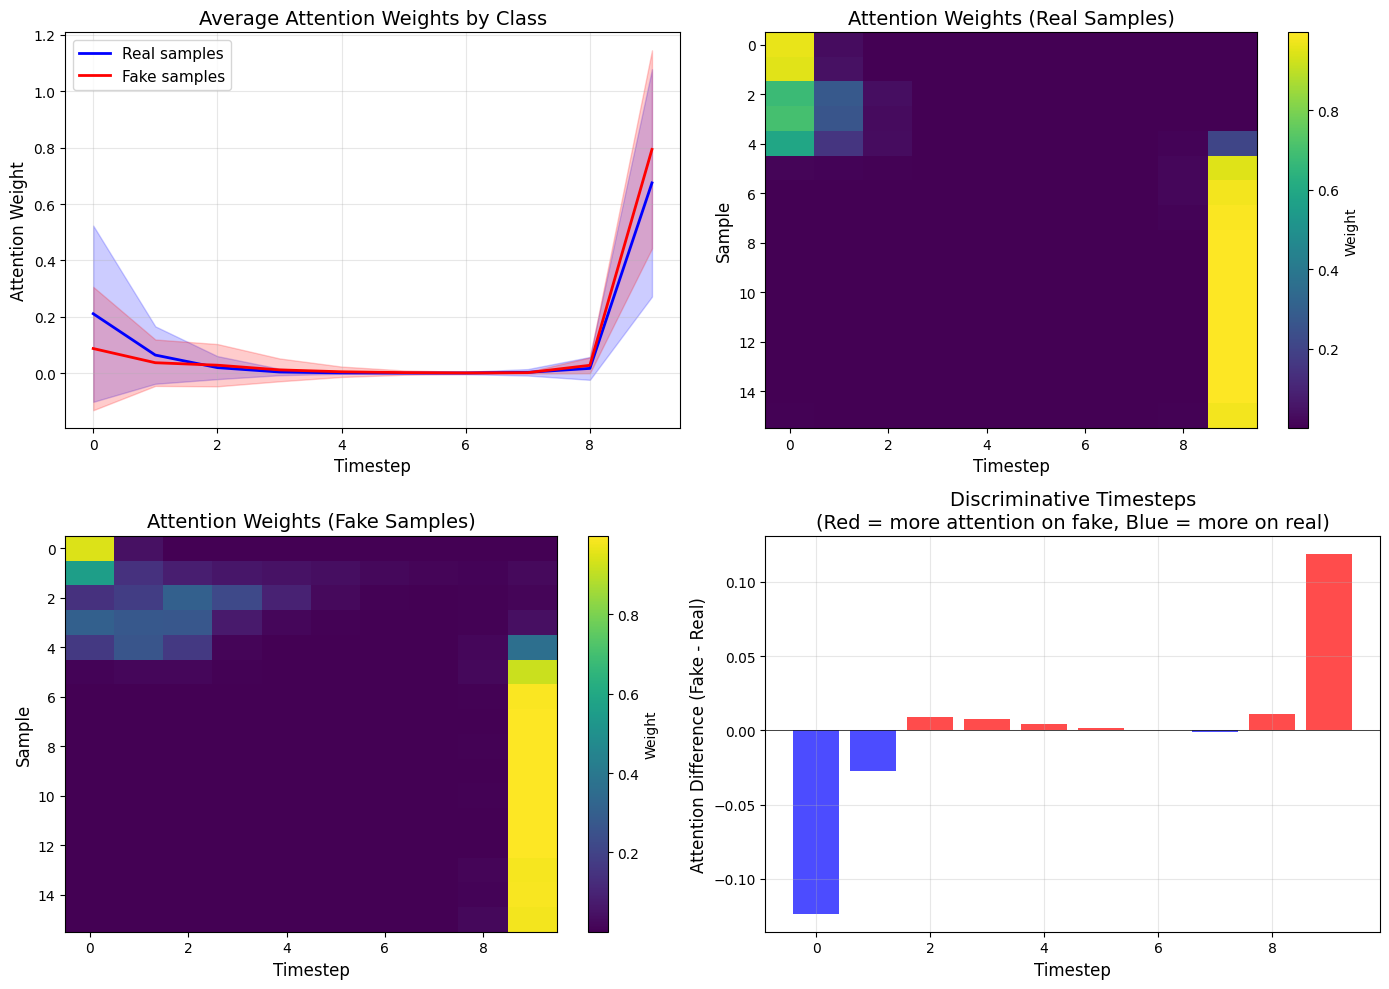


ATTENTION ANALYSIS
Timesteps with highest attention (Real): [9 0 1 2 8]
Timesteps with highest attention (Fake): [9 0 1 2 8]
Timesteps with largest difference (Fake > Real): [9 8 2 3 4]
Timesteps with largest difference (Real > Fake): [0 1 7 6 5]


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average attention across samples
avg_attn_real = np.mean(attn_real, axis=0)
avg_attn_fake = np.mean(attn_fake, axis=0)
std_attn_real = np.std(attn_real, axis=0)
std_attn_fake = np.std(attn_fake, axis=0)

timesteps = np.arange(len(avg_attn_real))

# Plot 1: Average attention patterns by class
ax1 = axes[0, 0]
ax1.plot(timesteps, avg_attn_real, label="Real samples", linewidth=2, color="blue")
ax1.fill_between(
    timesteps,
    avg_attn_real - std_attn_real,
    avg_attn_real + std_attn_real,
    alpha=0.2,
    color="blue",
)
ax1.plot(timesteps, avg_attn_fake, label="Fake samples", linewidth=2, color="red")
ax1.fill_between(
    timesteps,
    avg_attn_fake - std_attn_fake,
    avg_attn_fake + std_attn_fake,
    alpha=0.2,
    color="red",
)
ax1.set_xlabel("Timestep", fontsize=12)
ax1.set_ylabel("Attention Weight", fontsize=12)
ax1.set_title("Average Attention Weights by Class", fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Heatmap of real sample attentions
ax2 = axes[0, 1]
im2 = ax2.imshow(attn_real[:16], aspect="auto", cmap="viridis")
ax2.set_xlabel("Timestep", fontsize=12)
ax2.set_ylabel("Sample", fontsize=12)
ax2.set_title("Attention Weights (Real Samples)", fontsize=14)
plt.colorbar(im2, ax=ax2, label="Weight")

# Plot 3: Heatmap of fake sample attentions
ax3 = axes[1, 0]
im3 = ax3.imshow(attn_fake[:16], aspect="auto", cmap="viridis")
ax3.set_xlabel("Timestep", fontsize=12)
ax3.set_ylabel("Sample", fontsize=12)
ax3.set_title("Attention Weights (Fake Samples)", fontsize=14)
plt.colorbar(im3, ax=ax3, label="Weight")

# Plot 4: Difference in attention patterns
ax4 = axes[1, 1]
attn_diff = avg_attn_fake - avg_attn_real
colors = ["red" if d > 0 else "blue" for d in attn_diff]
ax4.bar(timesteps, attn_diff, color=colors, alpha=0.7)
ax4.axhline(y=0, color="k", linestyle="-", linewidth=0.5)
ax4.set_xlabel("Timestep", fontsize=12)
ax4.set_ylabel("Attention Difference (Fake - Real)", fontsize=12)
ax4.set_title(
    "Discriminative Timesteps\n(Red = more attention on fake, Blue = more on real)",
    fontsize=14,
)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 60)
print("ATTENTION ANALYSIS")
print("=" * 60)
print(
    f"Timesteps with highest attention (Real): {np.argsort(avg_attn_real)[-5:][::-1]}"
)
print(
    f"Timesteps with highest attention (Fake): {np.argsort(avg_attn_fake)[-5:][::-1]}"
)
print(
    f"Timesteps with largest difference (Fake > Real): {np.argsort(attn_diff)[-5:][::-1]}"
)
print(f"Timesteps with largest difference (Real > Fake): {np.argsort(attn_diff)[:5]}")
print("=" * 60)

## Feature Importance Analysis

Use gradient-based attribution to see which qpos dimensions (joints) the discriminator relies on most for classification.

In [24]:
# Compute gradient-based feature importance
# The gradient of the output logit w.r.t. input shows which features most influence the prediction


def compute_feature_importance(params, data):
    """Compute input gradients as a measure of feature importance."""

    def forward(x):
        logits = apply_fn(params, x, training=False)
        return logits.sum()  # Sum over batch for scalar output

    # Compute gradient of output w.r.t. input
    grads = jax.grad(forward)(data)
    return grads


# Compute gradients for real and fake samples
grads_real = compute_feature_importance(
    training_state.params.params, jnp.array(test_batch_real)
)
grads_fake = compute_feature_importance(
    training_state.params.params, jnp.array(test_batch_fake)
)

# Convert to numpy and take absolute value (magnitude of influence)
grads_real = np.abs(np.array(grads_real))
grads_fake = np.abs(np.array(grads_fake))

print(f"Gradient shape: {grads_real.shape}  # (num_samples, num_steps, qpos_dim)")

# Average over samples and time to get per-feature importance
# Shape: (num_samples, num_steps, qpos_dim) -> (qpos_dim,)
feature_importance_real = grads_real.mean(axis=(0, 1))
feature_importance_fake = grads_fake.mean(axis=(0, 1))

# Also compute time-averaged but sample-wise for variance
feature_importance_real_per_sample = grads_real.mean(axis=1)  # (num_samples, qpos_dim)
feature_importance_fake_per_sample = grads_fake.mean(axis=1)

feature_std_real = feature_importance_real_per_sample.std(axis=0)
feature_std_fake = feature_importance_fake_per_sample.std(axis=0)

print(f"Feature importance shape: {feature_importance_real.shape}")
print(
    f"Top 5 most important features (Real): {np.argsort(feature_importance_real)[-5:][::-1]}"
)
print(
    f"Top 5 most important features (Fake): {np.argsort(feature_importance_fake)[-5:][::-1]}"
)

Gradient shape: (32, 250, 74)  # (num_samples, num_steps, qpos_dim)
Feature importance shape: (74,)
Top 5 most important features (Real): [10 37 39 21 27]
Top 5 most important features (Fake): [10 37 39 21  7]


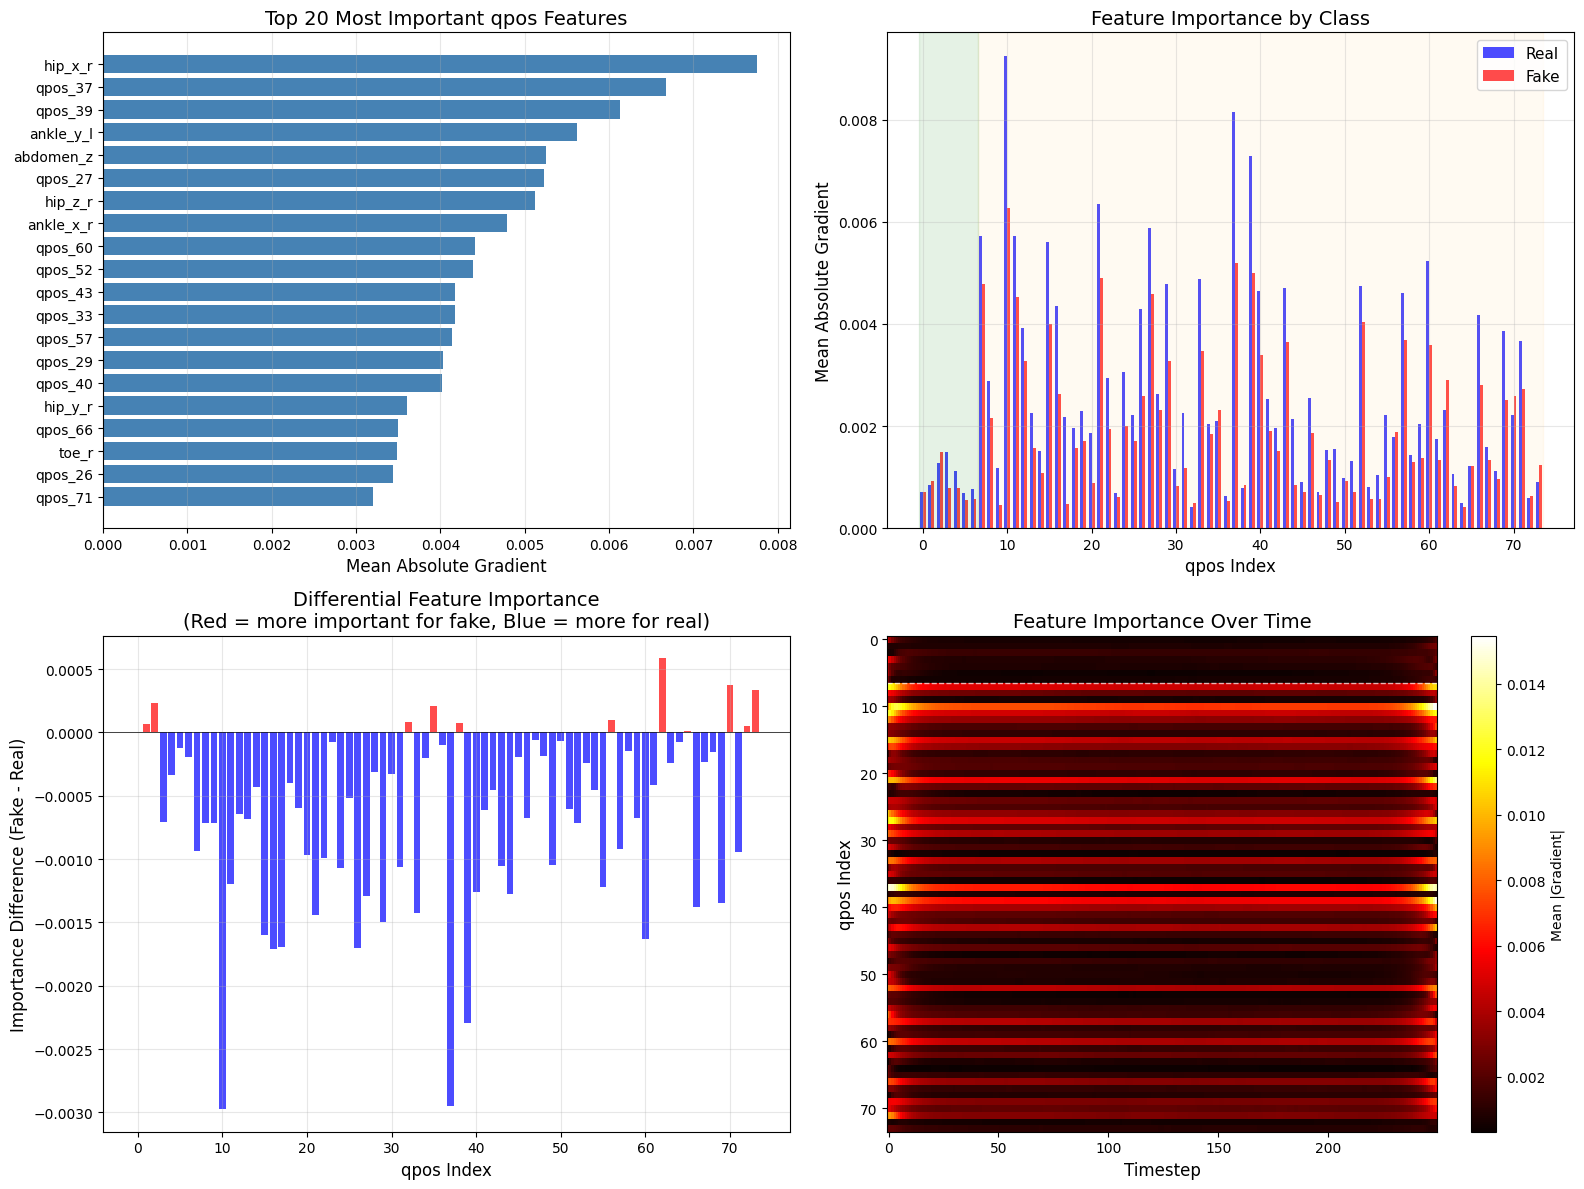

In [25]:
# Qpos feature names (approximate - based on typical humanoid structure)
# Indices 0-6: root (position xyz + quaternion wxyz)
# Indices 7+: joint angles
QPOS_LABELS = {
    0: "root_x",
    1: "root_y",
    2: "root_z",
    3: "root_qw",
    4: "root_qx",
    5: "root_qy",
    6: "root_qz",
    7: "abdomen_z",
    8: "abdomen_y",
    9: "abdomen_x",
    10: "hip_x_r",
    11: "hip_z_r",
    12: "hip_y_r",
    13: "knee_r",
    14: "ankle_y_r",
    15: "ankle_x_r",
    16: "toe_r",
    17: "hip_x_l",
    18: "hip_z_l",
    19: "hip_y_l",
    20: "knee_l",
    21: "ankle_y_l",
    22: "ankle_x_l",
    23: "toe_l",
    # Add more if needed...
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Bar chart of feature importance (averaged over real and fake)
ax1 = axes[0, 0]
combined_importance = (feature_importance_real + feature_importance_fake) / 2
sorted_indices = np.argsort(combined_importance)[::-1]
top_n = 20  # Show top 20 features

bars = ax1.barh(
    range(top_n), combined_importance[sorted_indices[:top_n]][::-1], color="steelblue"
)
ax1.set_yticks(range(top_n))
labels = [QPOS_LABELS.get(idx, f"qpos_{idx}") for idx in sorted_indices[:top_n][::-1]]
ax1.set_yticklabels(labels)
ax1.set_xlabel("Mean Absolute Gradient", fontsize=12)
ax1.set_title(f"Top {top_n} Most Important qpos Features", fontsize=14)
ax1.grid(True, alpha=0.3, axis="x")

# Plot 2: Comparison of real vs fake feature importance
ax2 = axes[0, 1]
x = np.arange(qpos_dim)
width = 0.35
ax2.bar(
    x - width / 2, feature_importance_real, width, label="Real", alpha=0.7, color="blue"
)
ax2.bar(
    x + width / 2, feature_importance_fake, width, label="Fake", alpha=0.7, color="red"
)
ax2.set_xlabel("qpos Index", fontsize=12)
ax2.set_ylabel("Mean Absolute Gradient", fontsize=12)
ax2.set_title("Feature Importance by Class", fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Highlight root vs joints
ax2.axvspan(-0.5, 6.5, alpha=0.1, color="green", label="Root")
ax2.axvspan(6.5, qpos_dim - 0.5, alpha=0.05, color="orange", label="Joints")

# Plot 3: Difference in feature importance (which features matter more for fake vs real)
ax3 = axes[1, 0]
importance_diff = feature_importance_fake - feature_importance_real
colors = ["red" if d > 0 else "blue" for d in importance_diff]
ax3.bar(x, importance_diff, color=colors, alpha=0.7)
ax3.axhline(y=0, color="k", linestyle="-", linewidth=0.5)
ax3.set_xlabel("qpos Index", fontsize=12)
ax3.set_ylabel("Importance Difference (Fake - Real)", fontsize=12)
ax3.set_title(
    "Differential Feature Importance\n(Red = more important for fake, Blue = more for real)",
    fontsize=14,
)
ax3.grid(True, alpha=0.3)

# Plot 4: Heatmap of feature importance over time (averaged across samples)
ax4 = axes[1, 1]
# Average gradients over samples: (num_samples, num_steps, qpos_dim) -> (num_steps, qpos_dim)
grads_over_time = (grads_real.mean(axis=0) + grads_fake.mean(axis=0)) / 2
im4 = ax4.imshow(grads_over_time.T, aspect="auto", cmap="hot", interpolation="nearest")
ax4.set_xlabel("Timestep", fontsize=12)
ax4.set_ylabel("qpos Index", fontsize=12)
ax4.set_title("Feature Importance Over Time", fontsize=14)
plt.colorbar(im4, ax=ax4, label="Mean |Gradient|")

# Add horizontal lines to separate root from joints
ax4.axhline(y=6.5, color="white", linestyle="--", linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()

In [26]:
# Summary statistics for feature importance
print("=" * 70)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 70)

# Group features
root_indices = list(range(7))
joint_indices = list(range(7, qpos_dim))

root_importance = combined_importance[root_indices].mean()
joint_importance = combined_importance[joint_indices].mean()

print(f"\nFeature group importance (mean |gradient|):")
print(f"  Root (indices 0-6):    {root_importance:.6f}")
print(f"  Joints (indices 7+):   {joint_importance:.6f}")
print(f"  Ratio (Root/Joints):   {root_importance/joint_importance:.2f}x")

print(f"\nTop 10 most important features:")
print(f"{'Rank':<6} {'Index':<8} {'Name':<20} {'Importance':<12}")
print("-" * 50)
for rank, idx in enumerate(sorted_indices[:10], 1):
    name = QPOS_LABELS.get(idx, f"qpos_{idx}")
    print(f"{rank:<6} {idx:<8} {name:<20} {combined_importance[idx]:.6f}")

print(f"\nFeatures with largest real vs fake difference:")
diff_sorted = np.argsort(np.abs(importance_diff))[::-1]
print(f"{'Index':<8} {'Name':<20} {'Diff (F-R)':<12} {'Direction':<10}")
print("-" * 55)
for idx in diff_sorted[:10]:
    name = QPOS_LABELS.get(idx, f"qpos_{idx}")
    direction = "Fake" if importance_diff[idx] > 0 else "Real"
    print(f"{idx:<8} {name:<20} {importance_diff[idx]:+.6f}   {direction}")

print("=" * 70)

FEATURE IMPORTANCE SUMMARY

Feature group importance (mean |gradient|):
  Root (indices 0-6):    0.000908
  Joints (indices 7+):   0.002433
  Ratio (Root/Joints):   0.37x

Top 10 most important features:
Rank   Index    Name                 Importance  
--------------------------------------------------
1      10       hip_x_r              0.007757
2      37       qpos_37              0.006670
3      39       qpos_39              0.006134
4      21       ankle_y_l            0.005623
5      7        abdomen_z            0.005247
6      27       qpos_27              0.005228
7      11       hip_z_r              0.005116
8      15       ankle_x_r            0.004794
9      60       qpos_60              0.004412
10     52       qpos_52              0.004385

Features with largest real vs fake difference:
Index    Name                 Diff (F-R)   Direction 
-------------------------------------------------------
10       hip_x_r              -0.002975   Real
37       qpos_37              